In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


=== Missing Values per Column ===
id                         0
name                       3
album_name                20
artists                    0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
duration_ms                0
lyrics                     0
year                       0
genre                      0
popularity                 0
total_artist_followers     0
avg_artist_popularity      0
artist_ids                 0
niche_genres               0
dtype: int64
=== After Replacing Missing Values ===
name                      0
album_name                0
artists                   0
danceability              0
energy                    0
key                       0
loudness                  0
mode                  

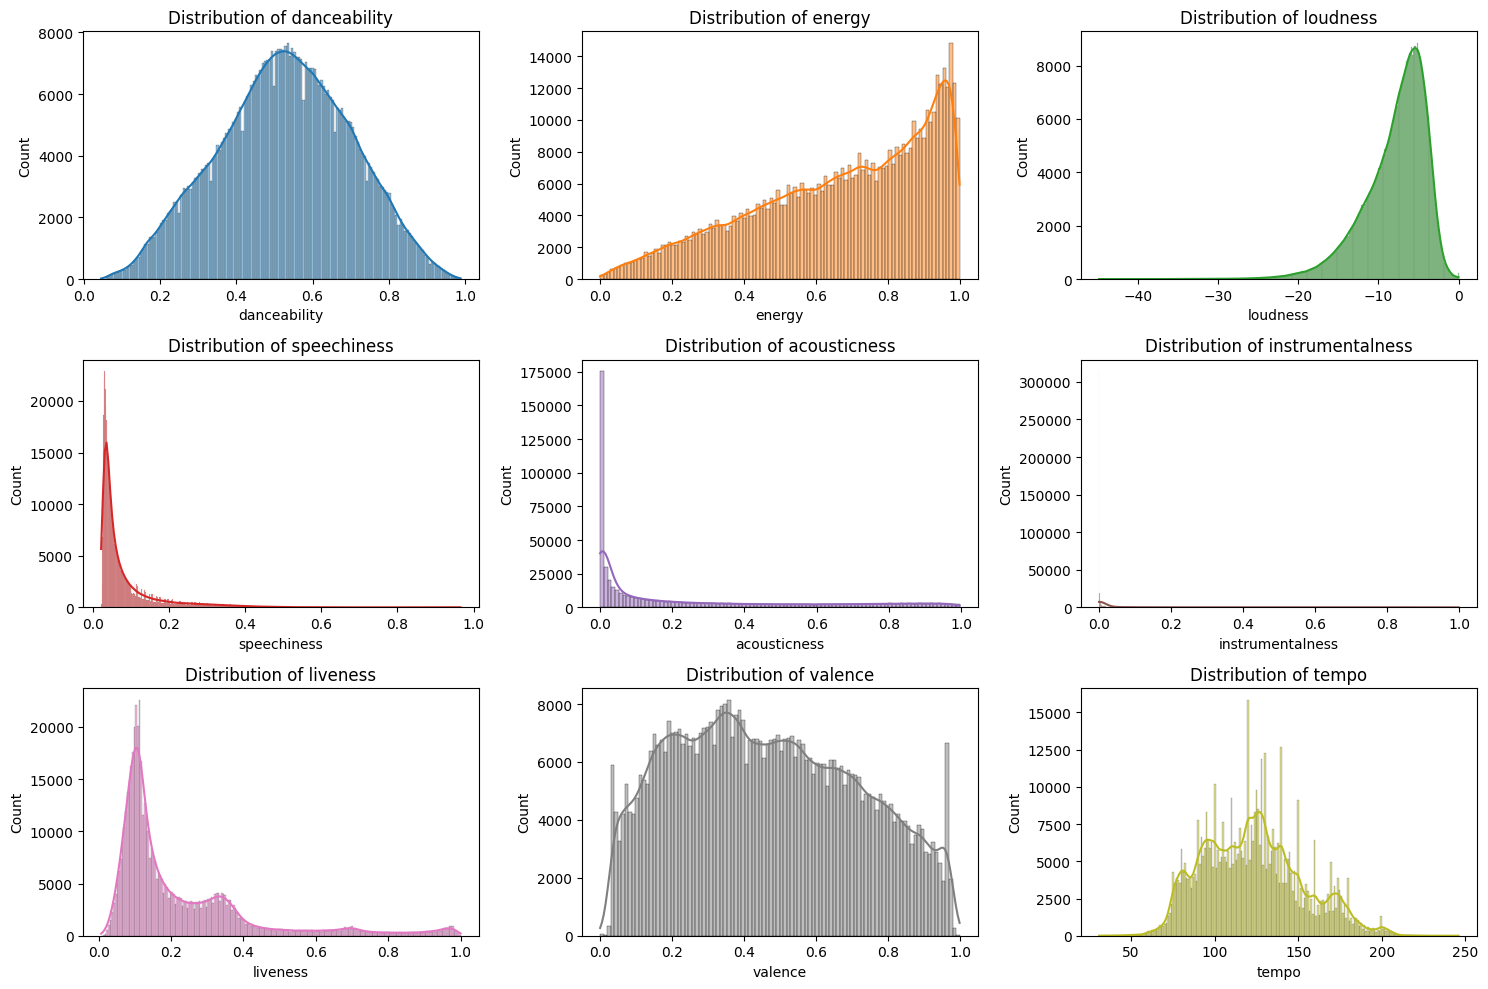

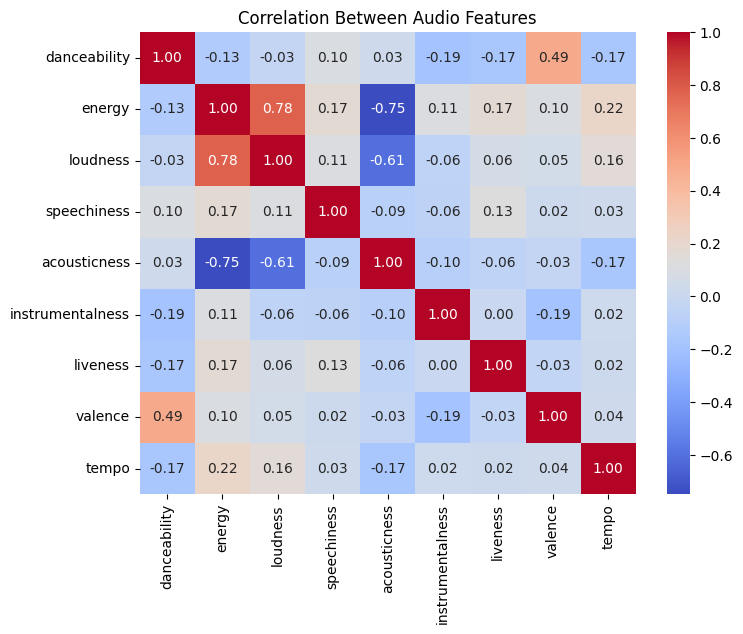

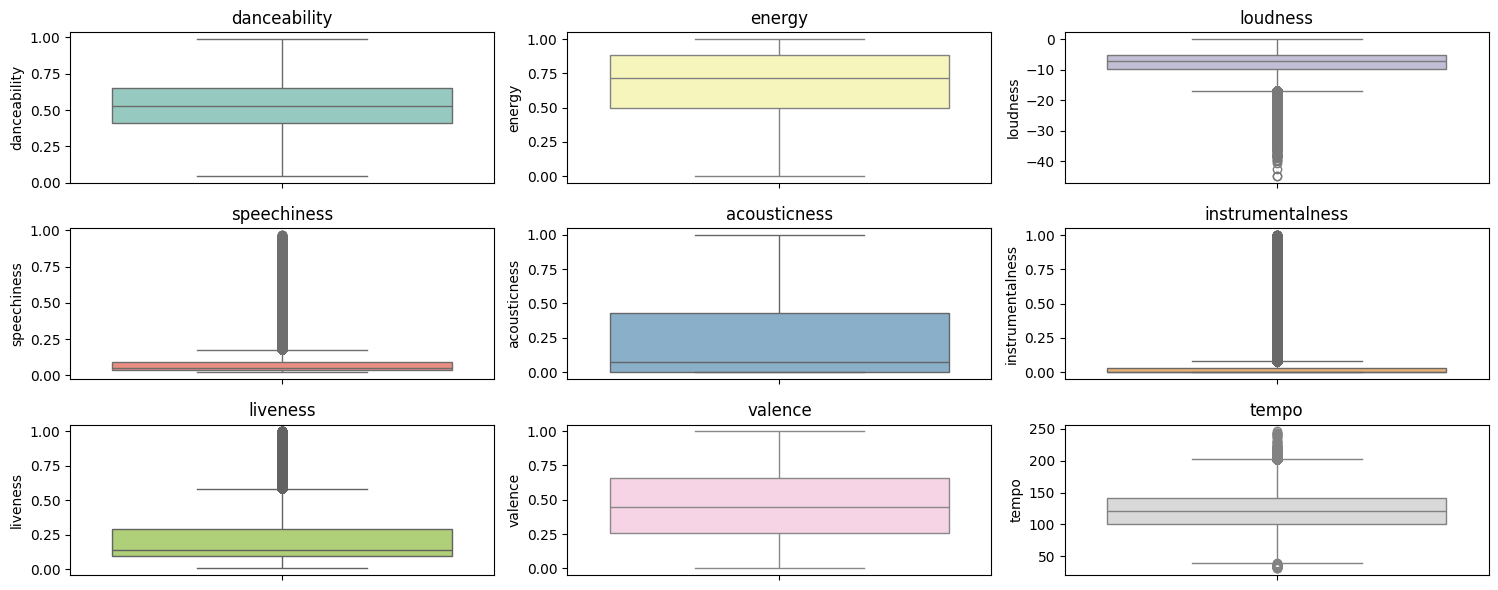

In [2]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/sabrina001/550k-music-dataset/songs.csv")  

# Keep only relevant numeric/audio features for this analysis and also they are the input dimension
audio_cols = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']

# Check for missing/null values
print("=== Missing Values per Column ===")
#print(df[audio_cols + ['lyrics','genre']].isnull().sum())
print(df.isnull().sum())
print("=== After Replacing Missing Values ===")

# Drop the 'id' column
df = df.drop(columns=['id'])

# Handling 'name' missing values (Replacing with "Unknown")
df['name'] = df['name'].fillna("Unknown Name")

# Handling 'album_name' missing values (Replacing with most common album)
df['album_name'] = df['album_name'].fillna(df['album_name'].mode()[0])

# Verify the results
print(df.isnull().sum())
print(df.head())

# Descriptive statistics
desc_stats = df[audio_cols].describe().T
print("=== Descriptive Statistics ===")
print(desc_stats)

# Add range (max - min) for each column
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
print("\n=== Descriptive Stats with Range ===")
print(desc_stats)

# Feature Distribution Plots
plt.figure(figsize=(15,10))
for i, col in enumerate(audio_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, color=sns.color_palette("tab10")[i])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Feature Distribution Plots (for all cols)
'''
cols = ['release_date','len']
plt.figure(figsize=(15,10))
for i, col in enumerate(cols):
    plt.subplot(1,2,i+1)
    sns.histplot(df[col], kde=True, color=sns.color_palette("tab10")[i])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()
'''

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[audio_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Audio Features")
plt.show()

# Boxplots to check for outliers
plt.figure(figsize=(15,6))
for i, col in enumerate(audio_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col], color=sns.color_palette("Set3")[i])
    plt.title(col)
plt.tight_layout()
plt.show()


In [3]:
# Take small subset
df = df.sample(25000, random_state=42)

print(df.shape)
df.head

(25000, 23)


<bound method NDFrame.head of                             name  \
313554             Naive Monarch   
210119  I Can't Live Without You   
136837              Erase It All   
460801              The Majestic   
19995   Ain't What It Used To Be   
...                          ...   
425787          Stone Cold Fever   
385951                Satellites   
141658      Exhaustion & Disgust   
191135                      Heat   
54212                  Big Girls   

                                               album_name  \
313554                                           Versions   
210119                           I Can't Live Without You   
136837                                          Hail Mary   
460801                         Cup of Sand (2017 Reissue)   
19995                                    Billy Currington   
...                                                   ...   
425787  20th Century Masters:The Millennium Collection...   
385951                            Periphery IV: H

In [4]:
feature_cols = [
    'danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

X = df[feature_cols].fillna(0).values

# StandardScaler is better for clustering and clustering distance-based metrics (Silhouette, Calinski-Harabasz)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# Create dataset
dataset = TensorDataset(X_tensor)

# Create DataLoader
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
# Min-Max scaling
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensor
#X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# check scaled values
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
print(df_scaled.head)

<bound method NDFrame.head of        danceability    energy  loudness  speechiness  acousticness  \
0         -0.758944  1.224340  0.995973    -0.242116     -0.788027   
1          1.030762  0.182282  0.079097    -0.453931     -0.787325   
2          0.106856  1.297610  1.142319     0.902744     -0.787835   
3         -0.944887  1.073730  1.041804    -0.249530     -0.748507   
4          0.734415  0.662606  1.044408    -0.536539     -0.366536   
...             ...       ...       ...          ...           ...   
24995     -1.078534  0.279975  0.059827    -0.316252     -0.780856   
24996      0.234692  0.275905  0.118418    -0.502649     -0.647215   
24997     -0.323139  0.878344  0.727498    -0.073723     -0.787155   
24998      1.664132 -0.143361  0.465273    -0.474054     -0.261976   
24999     -1.456232 -0.236983 -0.130006    -0.559839     -0.782686   

       instrumentalness  liveness   valence     tempo  
0             -0.447194  0.597706 -1.357518 -0.608894  
1              1.

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=5):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z


In [6]:
input_dim = X_scaled.shape[1]
print(input_dim)
print(feature_cols)

9
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [7]:
input_dim = X_scaled.shape[1]
model = VAE(input_dim).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-3)
epochs = 50
mse_history = []
kld_history = []
total_history = []
for epoch in range(epochs):
    model.train()    
    for (batch,) in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar, z = model(batch)
        recon_loss = nn.MSELoss()(recon, batch)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()
        
    mse_history.append(recon_loss.item())
    kld_history.append(kl_loss.item())
    total_history.append(loss.item())
    
    print(f"Epoch {epoch + 1}/{epochs}, MSE Loss: {recon_loss.item():.6f}, KLD Loss: {kl_loss.item():.6f}, Total Loss: {loss.item():.6f}")


Epoch 1/50, MSE Loss: 0.690295, KLD Loss: 0.147599, Total Loss: 0.837894
Epoch 2/50, MSE Loss: 0.702605, KLD Loss: 0.264872, Total Loss: 0.967476
Epoch 3/50, MSE Loss: 0.656826, KLD Loss: 0.203213, Total Loss: 0.860040
Epoch 4/50, MSE Loss: 0.689250, KLD Loss: 0.222921, Total Loss: 0.912171
Epoch 5/50, MSE Loss: 0.641523, KLD Loss: 0.181076, Total Loss: 0.822599
Epoch 6/50, MSE Loss: 0.667574, KLD Loss: 0.211824, Total Loss: 0.879398
Epoch 7/50, MSE Loss: 0.592405, KLD Loss: 0.210638, Total Loss: 0.803043
Epoch 8/50, MSE Loss: 0.579319, KLD Loss: 0.212625, Total Loss: 0.791944
Epoch 9/50, MSE Loss: 0.600621, KLD Loss: 0.282261, Total Loss: 0.882882
Epoch 10/50, MSE Loss: 0.580623, KLD Loss: 0.205734, Total Loss: 0.786356
Epoch 11/50, MSE Loss: 0.573022, KLD Loss: 0.295252, Total Loss: 0.868273
Epoch 12/50, MSE Loss: 0.660701, KLD Loss: 0.253300, Total Loss: 0.914001
Epoch 13/50, MSE Loss: 0.543437, KLD Loss: 0.199770, Total Loss: 0.743207
Epoch 14/50, MSE Loss: 0.480480, KLD Loss: 0.26

In [8]:
model.eval()
with torch.no_grad():
    recon, mu, logvar, z = model(X_tensor.to(device))
    latent_features = mu.cpu().numpy()

VAE + KMeans
Silhouette: 0.4095558
Calinski-Harabasz: 19032.191


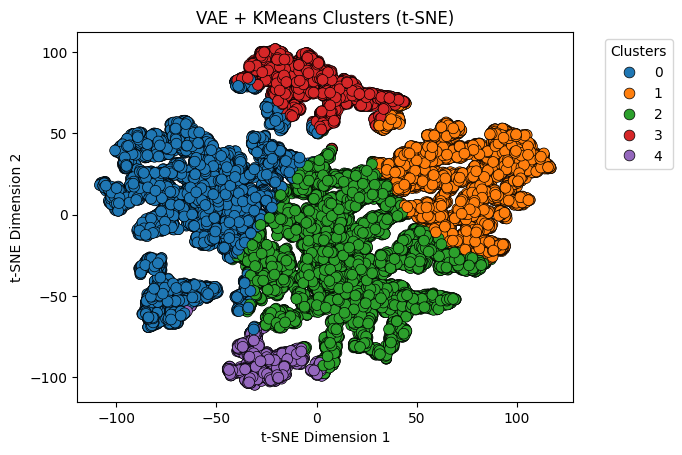

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_vae = kmeans.fit_predict(latent_features)

sil_vae = silhouette_score(latent_features, clusters_vae)
ch_vae = calinski_harabasz_score(latent_features, clusters_vae)

print("VAE + KMeans")
print("Silhouette:", sil_vae)
print("Calinski-Harabasz:", ch_vae)

# t-SNE
tsne_vae = TSNE(n_components=2, perplexity=50, random_state=42)
vae_2d = tsne_vae.fit_transform(latent_features)

sns.scatterplot(x=vae_2d[:,0], y=vae_2d[:,1], hue=clusters_vae, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("VAE + KMeans Clusters (t-SNE)")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


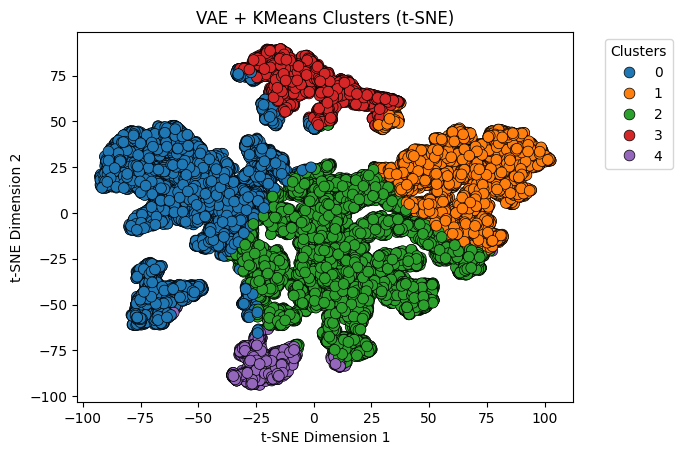

In [38]:
# t-SNE
tsne_vae = TSNE(n_components=2, perplexity=80, random_state=42)
vae_2d = tsne_vae.fit_transform(latent_features)

sns.scatterplot(x=vae_2d[:,0], y=vae_2d[:,1], hue=clusters_vae, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("VAE + KMeans Clusters (t-SNE)")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

             danceability    energy  loudness  speechiness  acousticness  \
vae_cluster                                                                
0                0.389627  0.856015  0.845582     0.070995      0.057893   
1                0.481506  0.310503  0.652663     0.022413      0.710354   
2                0.621948  0.689448  0.798779     0.051121      0.178726   
3                0.407515  0.764475  0.783001     0.053987      0.123838   
4                0.691831  0.652663  0.772820     0.392781      0.250505   

             instrumentalness  liveness   valence     tempo  
vae_cluster                                                  
0                    0.051488  0.324919  0.374602  0.538597  
1                    0.045366  0.148844  0.379851  0.420645  
2                    0.027366  0.150373  0.617034  0.456661  
3                    0.760240  0.181483  0.323676  0.491316  
4                    0.009815  0.278058  0.624153  0.430259  


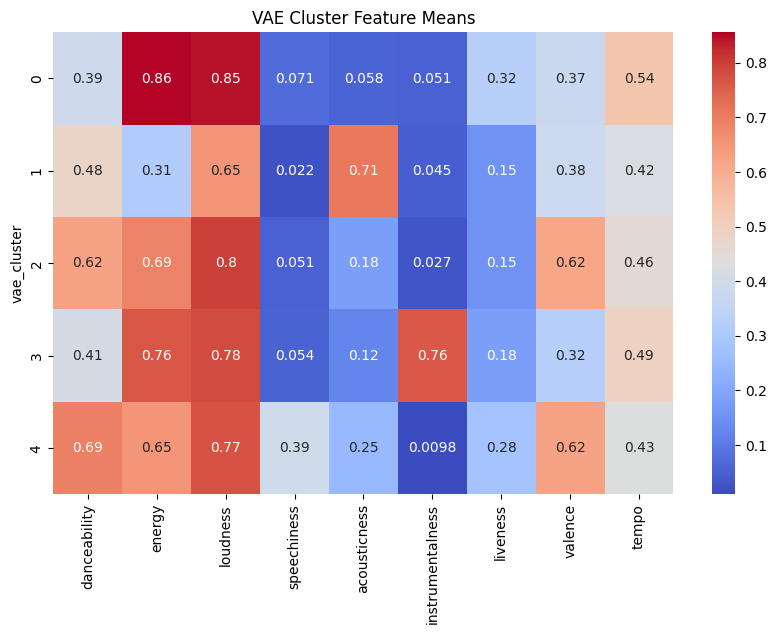

(VAE) Each Cluster Size: 


vae_cluster
2    8908
0    7722
1    4829
3    2391
4    1150
Name: count, dtype: int64

In [36]:
# Interpretation example:
# Cluster 0 -> high energy + loudness -> dance/party music
# Cluster 1 -> high acousticness -> acoustic songs

df['vae_cluster'] = clusters_vae

scaler_mm_vae = MinMaxScaler()
df_mm_vae = df.copy()
df_mm_vae[feature_cols] = scaler_mm_vae.fit_transform(df[feature_cols])

cluster_summary_vae = df_mm_vae.groupby('vae_cluster')[feature_cols].mean()
print(cluster_summary_vae)

# heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary_vae, annot=True, cmap='coolwarm')
plt.title("VAE Cluster Feature Means")
plt.show()

# Check cluster size
print("(VAE) Each Cluster Size: ")
df['vae_cluster'].value_counts()


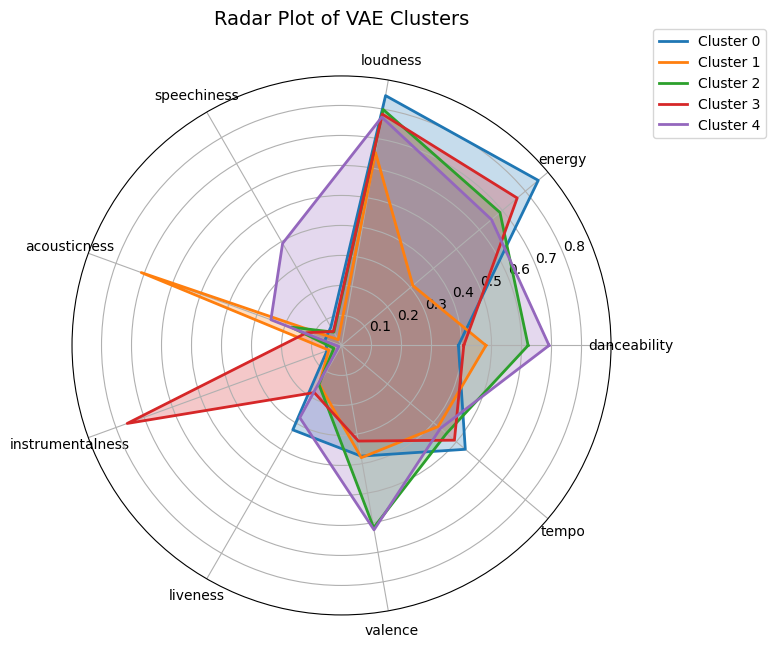

In [33]:
# Radar / Spider Plot

cluster_summary_vae = df_mm_vae.groupby('vae_cluster')[feature_cols].mean()

labels = feature_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
colors = sns.color_palette("tab10", len(cluster_summary_vae))

for i, color in zip(cluster_summary_vae.index, colors):
    values = cluster_summary_vae.loc[i].values.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {i}", color=color, linewidth=2)
    plt.fill(angles, values, color=color, alpha=0.25)
    
plt.xticks(angles[:-1], labels, rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Radar Plot of VAE Clusters", size=14, color='black', y=1.08)
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
vae_cluster                                                                
0               -0.116140  0.182831  0.063273     0.003290     -0.184252   
1               -0.024262 -0.362681 -0.129645    -0.045292      0.468209   
2                0.116181  0.016264  0.016470    -0.016584     -0.063419   
3               -0.098252  0.091291  0.000692    -0.013717     -0.118306   
4                0.186063 -0.020521 -0.009489     0.325077      0.008360   

             instrumentalness  liveness   valence     tempo  
vae_cluster                                                  
0                   -0.056090  0.112079 -0.094006  0.061484  
1                   -0.062212 -0.063997 -0.088757 -0.056467  
2                   -0.080213 -0.062467  0.148426 -0.020451  
3                    0.652661 -0.031357 -0.144932  0.014203  
4                   -0.097763  0.065218  0.155545 -0.046854  


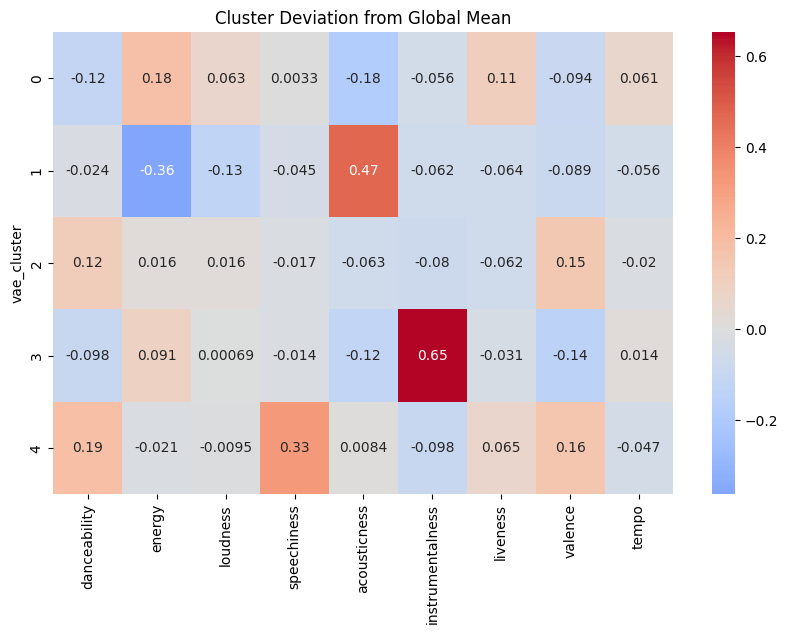

In [13]:
# Feature Importance per Cluster (Difference from Global Mean)
# If value is positive = feature is stronger in that cluster
# If value is negative = feature is weaker
overall_mean = df_mm_vae[feature_cols].mean()
diff = cluster_summary_vae - overall_mean
print(diff)

plt.figure(figsize=(10,6))
sns.heatmap(diff, annot=True, cmap='coolwarm', center=0)
plt.title("Cluster Deviation from Global Mean")
plt.show()


Min: -0.14142562
Max: 0.6431383


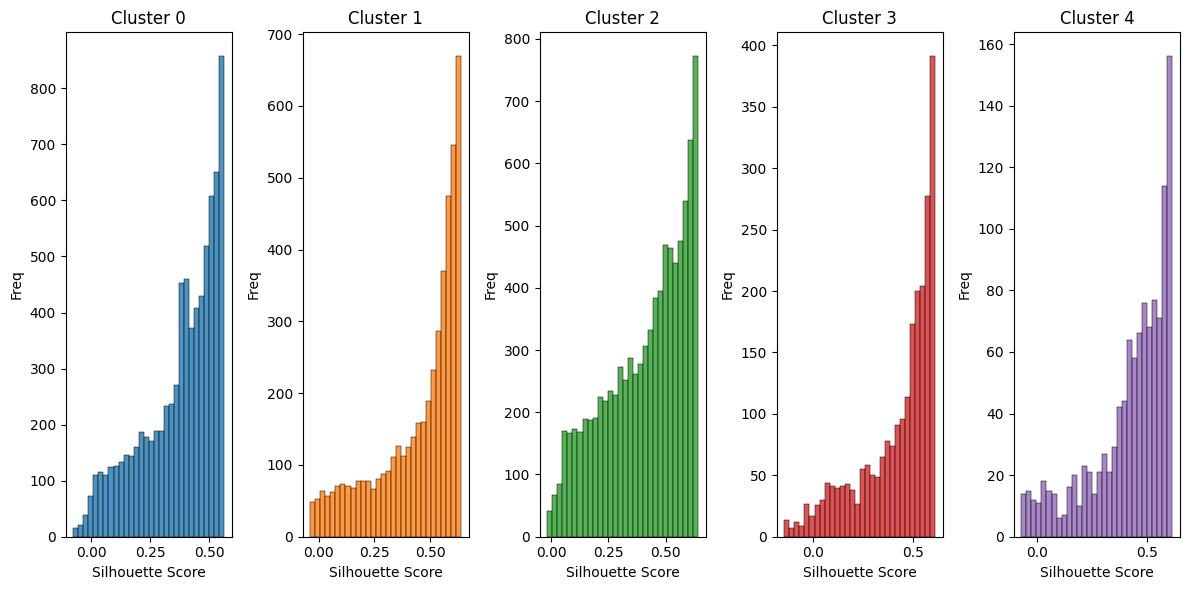

In [14]:
# Silhouette Plot (show silhouette per sample)
from sklearn.metrics import silhouette_samples
sil_vae = silhouette_samples(latent_features, clusters_vae)

print("Min:", sil_vae.min())
print("Max:", sil_vae.max())

unique_clusters = np.unique(clusters_vae)
colors = sns.color_palette("tab10", len(unique_clusters))

plt.figure(figsize=(12, 6))

for i, c in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i+1)
    
    sns.histplot(
        sil_vae[clusters_vae == c],
        bins=30,
        color=colors[i],   
        edgecolor='black',
        alpha=0.8
    )
    
    plt.title(f'Cluster {c}')
    plt.xlabel("Silhouette Score")
    plt.ylabel("Freq")

plt.tight_layout()
plt.show()


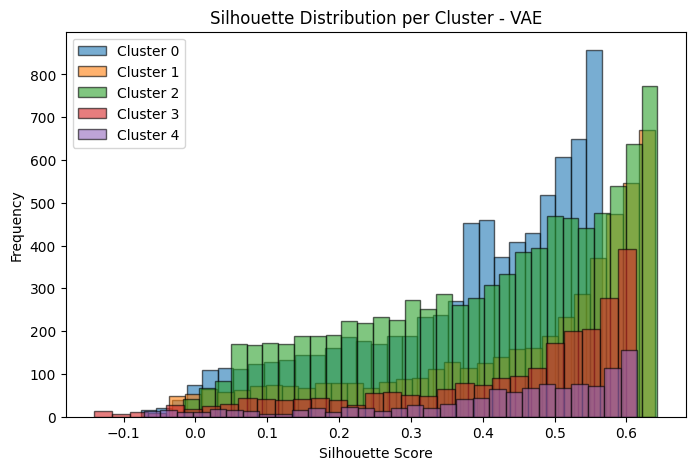

In [15]:

from sklearn.metrics import silhouette_samples

unique_clusters = np.unique(clusters_vae)

plt.figure(figsize=(8,5))

for c in unique_clusters:
    plt.hist(
        sil_vae[clusters_vae == c],
        bins=30,
        alpha=0.6,
        edgecolor='black',
        label=f'Cluster {c}'
    )

plt.title("Silhouette Distribution per Cluster - VAE")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Average silhouette score (red dashed line): 0.4095558
Cluster 0 average silhouette: 0.37626806
Cluster 1 average silhouette: 0.4479282
Cluster 2 average silhouette: 0.41213852
Cluster 3 average silhouette: 0.42407888
Cluster 4 average silhouette: 0.4217433


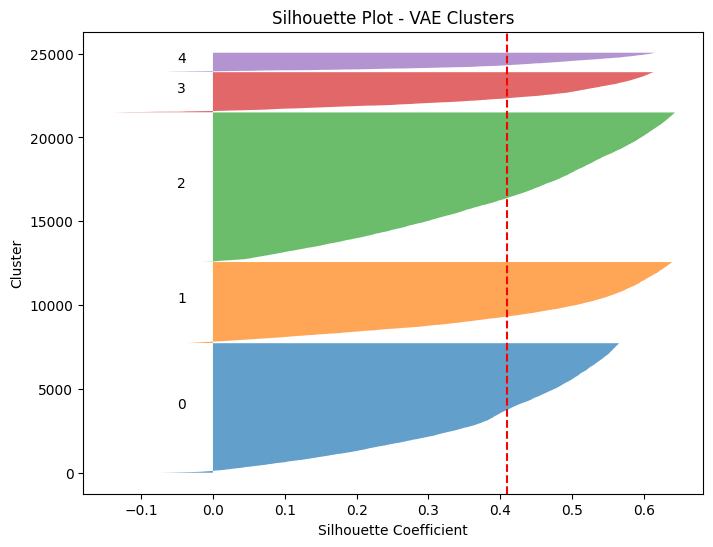

In [16]:
'''
This shows:
Thickness -> cluster size
Width -> cluster compactness
Negative area -> bad separation
Red line -> average silhouette score
'''
y_lower = 10
unique_clusters = np.unique(clusters_vae)

plt.figure(figsize=(8,6))

for c in unique_clusters:
    cluster_sil_vae = sil_vae[clusters_vae == c]
    cluster_sil_vae.sort()
    
    size_cluster = cluster_sil_vae.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil_vae,
        alpha=0.7
    )
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(c))
    
    y_lower = y_upper + 10

avg_silhouette = np.mean(sil_vae)
print("Average silhouette score (red dashed line):", avg_silhouette)
for c in np.unique(clusters_vae):
    cluster_avg = sil_vae[clusters_vae == c].mean()
    print(f"Cluster {c} average silhouette:", cluster_avg)

plt.axvline(x=np.mean(sil_vae), color="red", linestyle="--")
plt.title("Silhouette Plot - VAE Clusters")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.show()


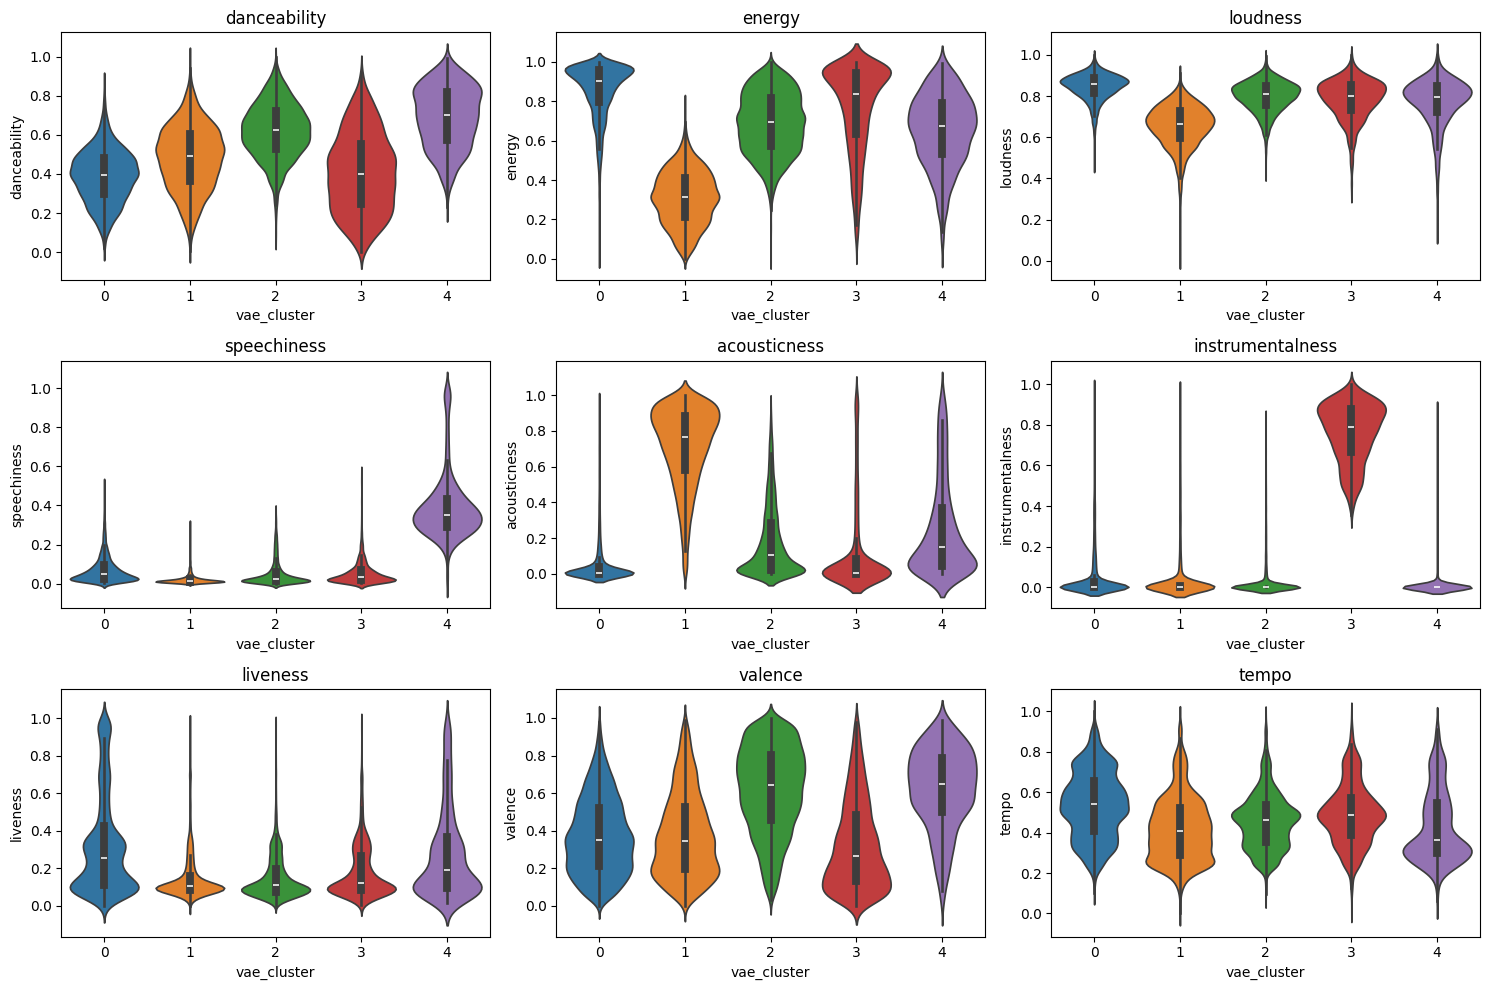

In [17]:
plt.figure(figsize=(15,10))

for i, feature in enumerate(feature_cols):
    plt.subplot(3,3,i+1)
    sns.violinplot(
        x='vae_cluster',
        y=feature,
        data=df_mm_vae,
        hue='vae_cluster',
        palette='tab10',
        legend=False
    )
    plt.title(feature)

plt.tight_layout()
plt.show()


In [18]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, clusters_pca)
ch_pca = calinski_harabasz_score(X_pca, clusters_pca)

print("\nPCA + KMeans")
print("Silhouette:", sil_pca)
print("Calinski-Harabasz:", ch_pca)



PCA + KMeans
Silhouette: 0.23876868683308916
Calinski-Harabasz: 6870.090823056836


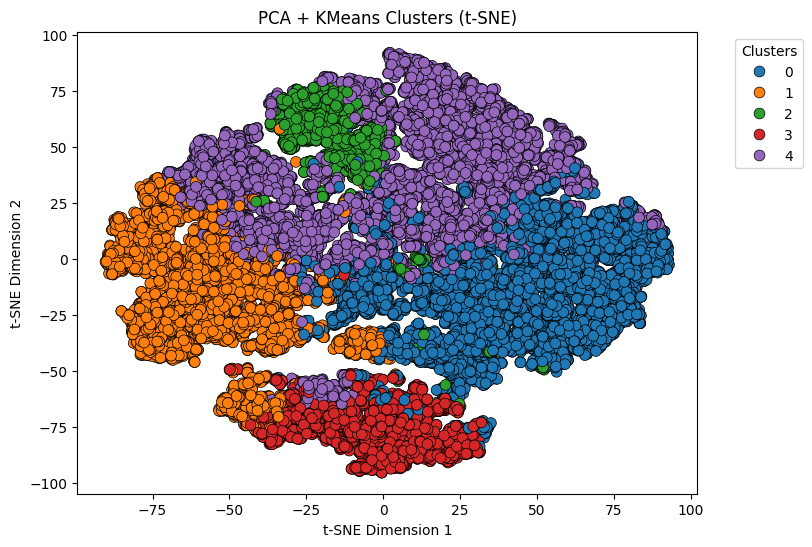

In [39]:
# t-SNE for visualization
tsne_pca = TSNE(n_components=2, perplexity=50, random_state=42)
pca_2d = tsne_pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=clusters_pca, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("PCA + KMeans Clusters (t-SNE)")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


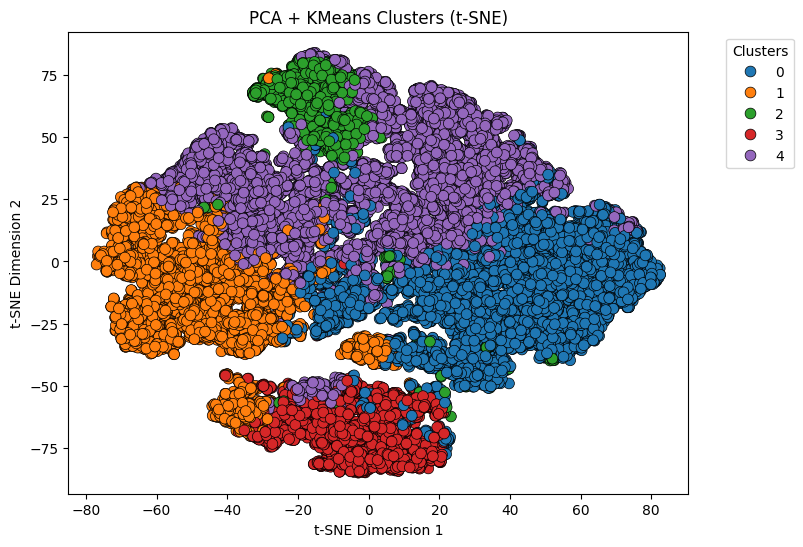

In [41]:
# t-SNE for visualization
tsne_pca = TSNE(n_components=2, perplexity=80, random_state=42)
pca_2d = tsne_pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=clusters_pca, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("PCA + KMeans Clusters (t-SNE)")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
pca_cluster                                                                
0                0.385632  0.849929  0.847174     0.064187      0.053935   
1                0.469298  0.313335  0.648753     0.024823      0.699392   
2                0.660700  0.679196  0.785307     0.338138      0.241736   
3                0.395301  0.805662  0.800356     0.058628      0.069630   
4                0.639466  0.697299  0.801281     0.042185      0.177771   

             instrumentalness  liveness   valence     tempo  
pca_cluster                                                  
0                    0.034849  0.299328  0.373392  0.549614  
1                    0.069218  0.176616  0.364648  0.425326  
2                    0.018393  0.313051  0.594569  0.447018  
3                    0.719163  0.194518  0.303614  0.491258  
4                    0.031182  0.140160  0.645200  0.445547  


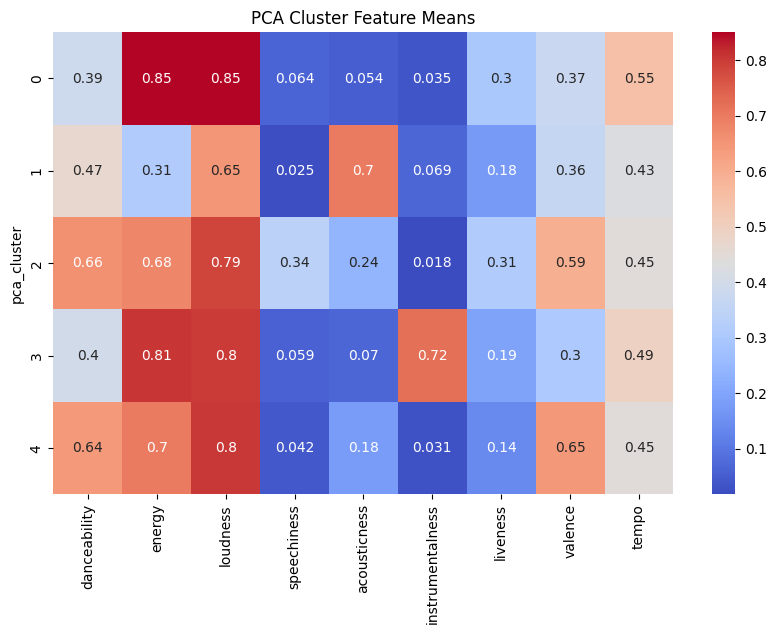

(PCA) Each Cluster Size: 


pca_cluster
4    8125
0    7469
1    5157
3    2484
2    1765
Name: count, dtype: int64

In [21]:
df['pca_cluster'] = clusters_pca

scaler_mm_pca = MinMaxScaler()
df_mm_pca = df.copy()
df_mm_pca[feature_cols] = scaler_mm_pca.fit_transform(df[feature_cols])
cluster_summary_pca = df_mm_pca.groupby('pca_cluster')[feature_cols].mean()
print(cluster_summary_pca)

# heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary_pca, annot=True, cmap='coolwarm')
plt.title("PCA Cluster Feature Means")
plt.show()

# Check cluster size
print("(PCA) Each Cluster Size: ")
df['pca_cluster'].value_counts()


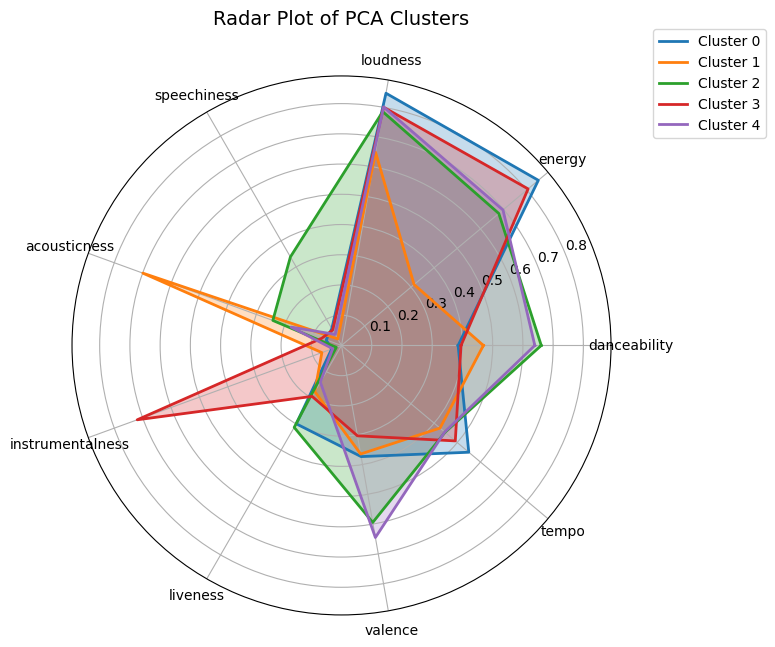

In [23]:
# Radar / Spider Plot

cluster_summary_pca = df_mm_pca.groupby('pca_cluster')[feature_cols].mean()

labels = feature_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
colors = sns.color_palette("tab10", len(cluster_summary_vae))

for i, color in zip(cluster_summary_pca.index, colors):
    values = cluster_summary_pca.loc[i].values.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {i}", color=color, linewidth=2)
    plt.fill(angles, values, color=color, alpha=0.25)

plt.xticks(angles[:-1], labels, rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Radar Plot of PCA Clusters", size=14, color='black', y=1.08)
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
pca_cluster                                                                
0               -0.120135  0.176745  0.064865    -0.003518     -0.188210   
1               -0.036469 -0.359849 -0.133556    -0.042882      0.457247   
2                0.154932  0.006012  0.002999     0.270433     -0.000409   
3               -0.110466  0.132479  0.018047    -0.009077     -0.172515   
4                0.133699  0.024116  0.018972    -0.025520     -0.064374   

             instrumentalness  liveness   valence     tempo  
pca_cluster                                                  
0                   -0.072730  0.086487 -0.095216  0.072501  
1                   -0.038360 -0.036224 -0.103960 -0.051786  
2                   -0.089186  0.100211  0.125961 -0.030095  
3                    0.611584 -0.018322 -0.164994  0.014145  
4                   -0.076396 -0.072680  0.176592 -0.031565  


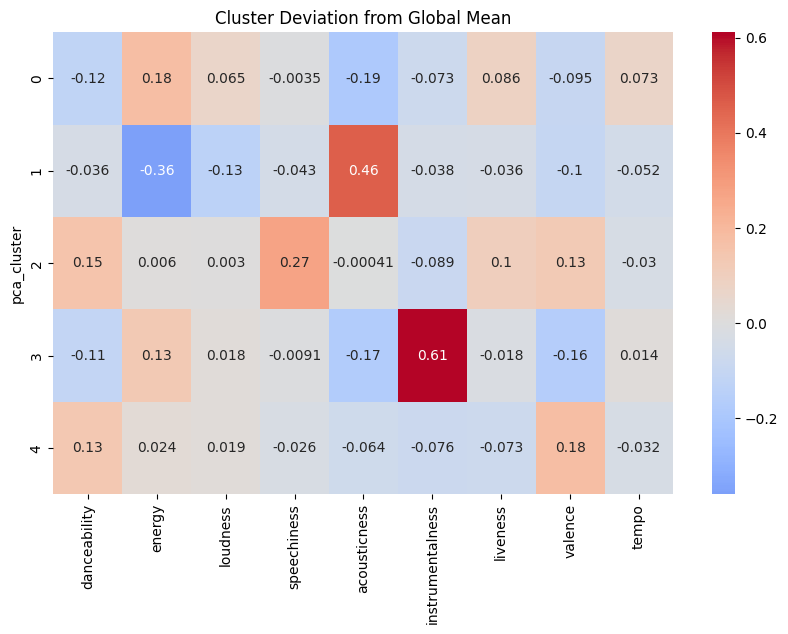

In [24]:
# Feature Importance per Cluster (Difference from Global Mean)
overall_mean = df_mm_pca[feature_cols].mean()
diff = cluster_summary_pca - overall_mean
print(diff)

plt.figure(figsize=(10,6))
sns.heatmap(diff, annot=True, cmap='coolwarm', center=0)
plt.title("Cluster Deviation from Global Mean")
plt.show()


Min: -0.77795875
Max: 0.6324904


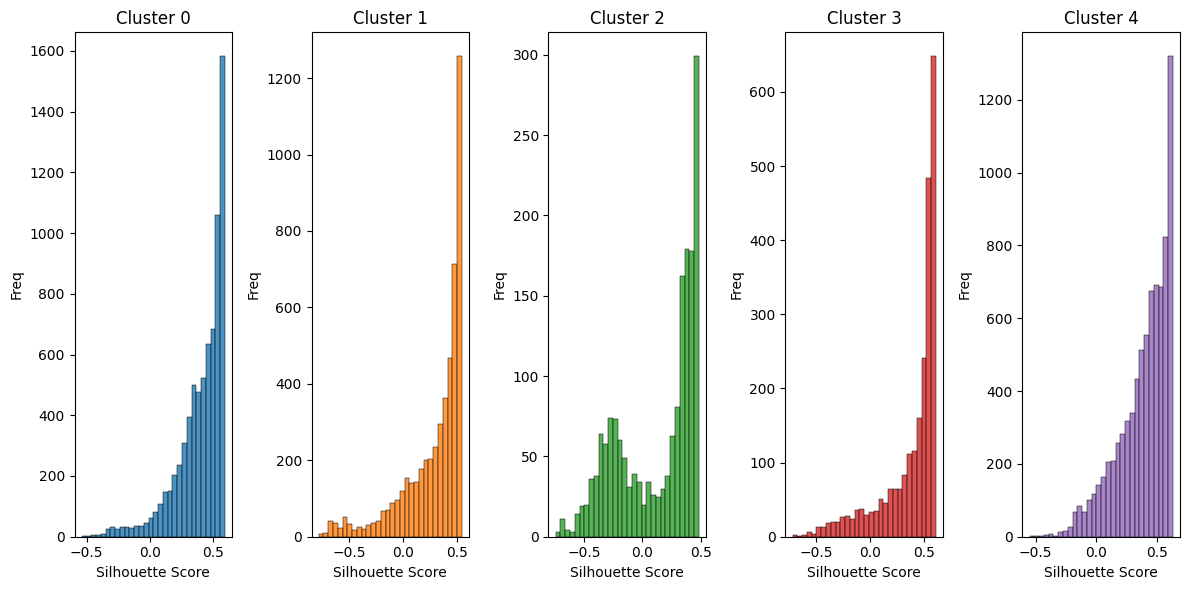

In [25]:
# Silhouette Plot (show silhouette per sample)
from sklearn.metrics import silhouette_samples
sil_pca = silhouette_samples(latent_features, clusters_pca)

print("Min:", sil_pca.min())
print("Max:", sil_pca.max())

unique_clusters = np.unique(clusters_pca)
colors = sns.color_palette("tab10", len(unique_clusters))

plt.figure(figsize=(12, 6))

for i, c in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i+1)
    
    sns.histplot(
        sil_pca[clusters_pca == c],
        bins=30,
        color=colors[i],   
        edgecolor='black',
        alpha=0.8
    )
    
    plt.title(f'Cluster {c}')
    plt.xlabel("Silhouette Score")
    plt.ylabel("Freq")

plt.tight_layout()
plt.show()


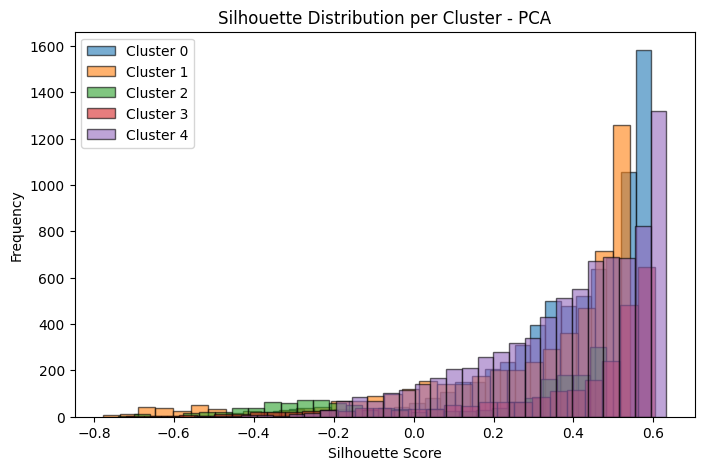

In [26]:

from sklearn.metrics import silhouette_samples

unique_clusters = np.unique(clusters_pca)

plt.figure(figsize=(8,5))

for c in unique_clusters:
    plt.hist(
        sil_pca[clusters_pca == c],
        bins=30,
        alpha=0.6,
        edgecolor='black',
        label=f'Cluster {c}'
    )

plt.title("Silhouette Distribution per Cluster - PCA")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Average silhouette score (red dashed line): 0.35177386
Cluster 0 average silhouette: 0.40166876
Cluster 1 average silhouette: 0.2842408
Cluster 2 average silhouette: 0.12637214
Cluster 3 average silhouette: 0.37816733
Cluster 4 average silhouette: 0.38966623


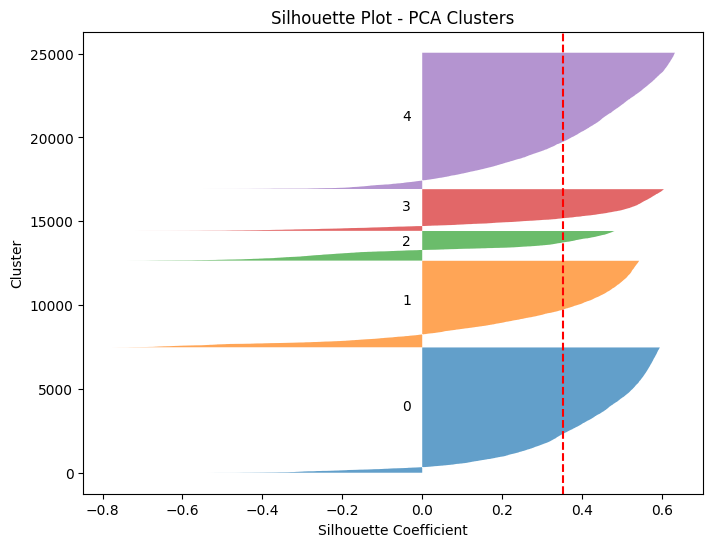

In [27]:
'''
This shows:
Thickness -> cluster size
Width -> cluster compactness
Negative area -> bad separation
Red line -> average silhouette score
'''
y_lower = 10
unique_clusters = np.unique(clusters_pca)

plt.figure(figsize=(8,6))

for c in unique_clusters:
    cluster_sil_pca = sil_pca[clusters_pca == c]
    cluster_sil_pca.sort()
    
    size_cluster = cluster_sil_pca.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil_pca,
        alpha=0.7
    )
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(c))
    
    y_lower = y_upper + 10

avg_silhouette = np.mean(sil_pca)
print("Average silhouette score (red dashed line):", avg_silhouette)
for c in np.unique(clusters_pca):
    cluster_avg = sil_pca[clusters_pca == c].mean()
    print(f"Cluster {c} average silhouette:", cluster_avg)
plt.axvline(x=np.mean(sil_pca), color="red", linestyle="--")
plt.title("Silhouette Plot - PCA Clusters")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.show()


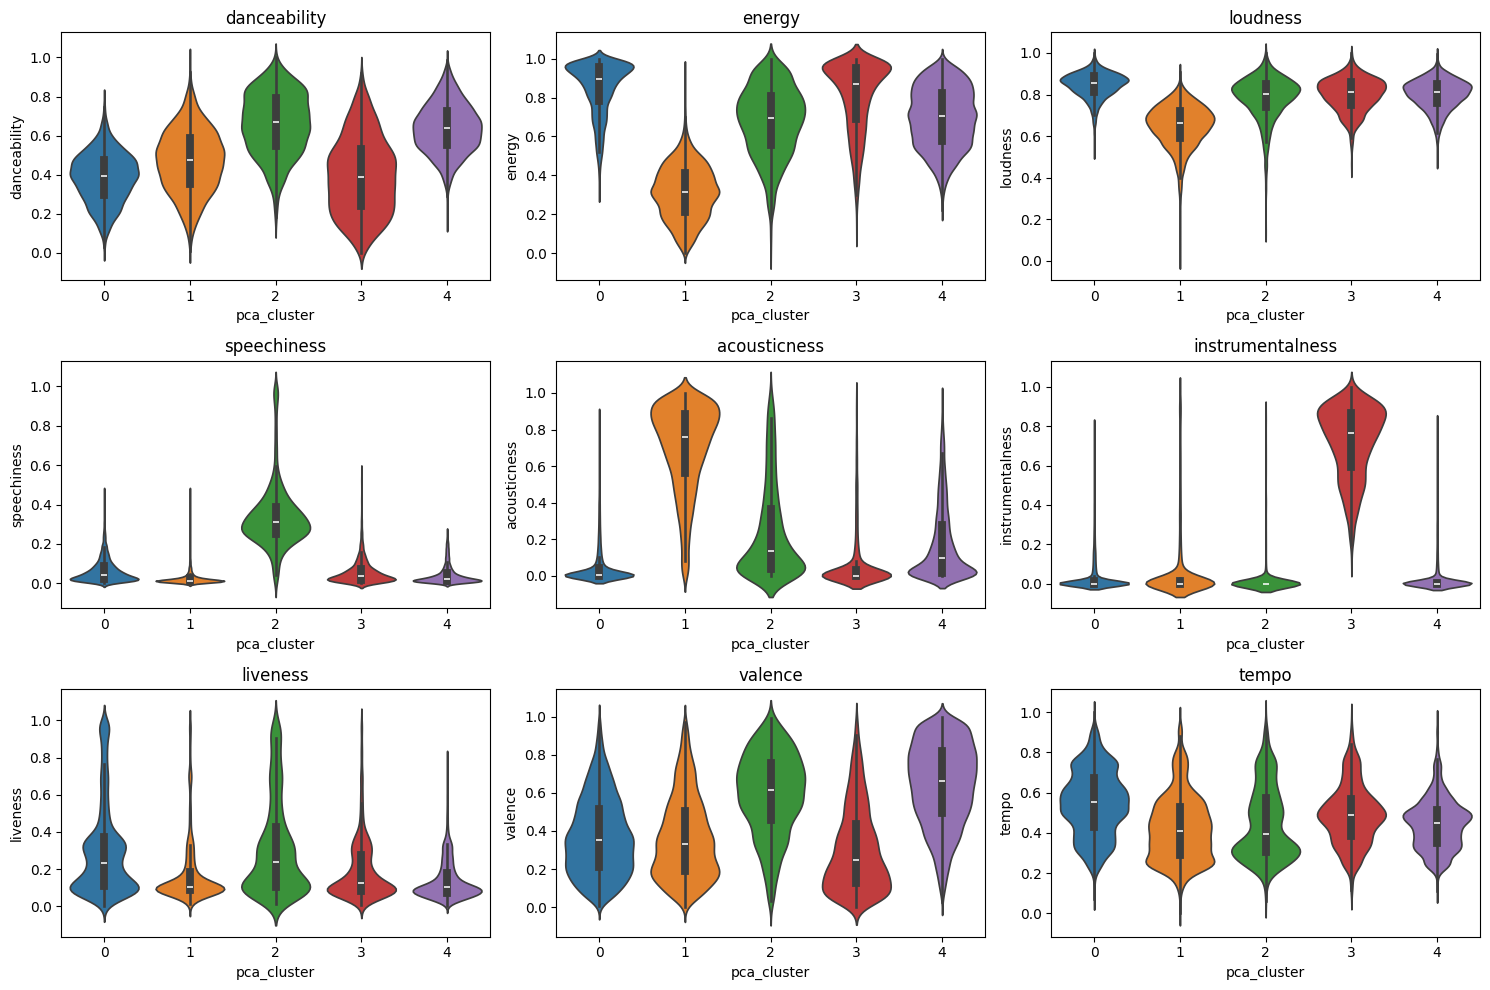

In [28]:
plt.figure(figsize=(15,10))

for i, feature in enumerate(feature_cols):
    plt.subplot(3,3,i+1)
    sns.violinplot(
        x='pca_cluster',
        y=feature,
        data=df_mm_pca,
        hue='pca_cluster',
        palette='tab10',
        legend=False
    )
    plt.title(feature)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


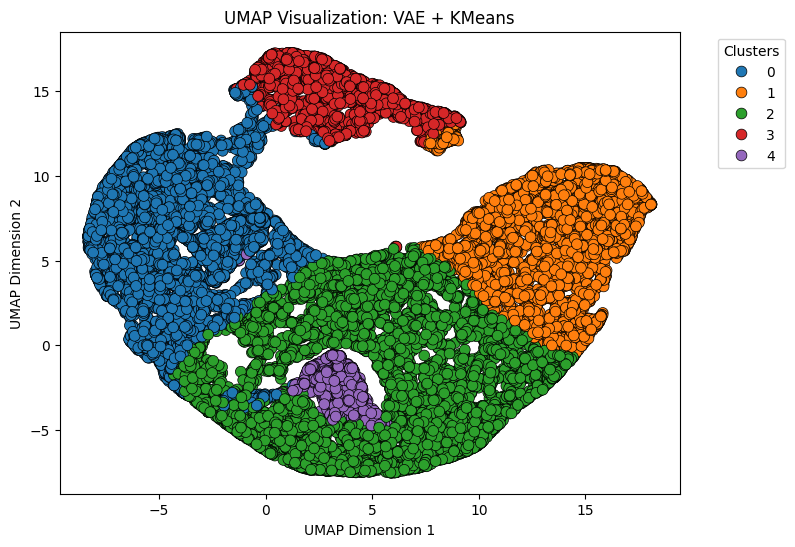

In [42]:
import umap
# KMeans
kmeans_vae = KMeans(n_clusters=5, random_state=42)
clusters_vae = kmeans_vae.fit_predict(latent_features)

# UMAP 2D
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
vae_umap_2d = reducer.fit_transform(latent_features)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x = vae_umap_2d[:,0], y =vae_umap_2d[:,1], hue=clusters_vae, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


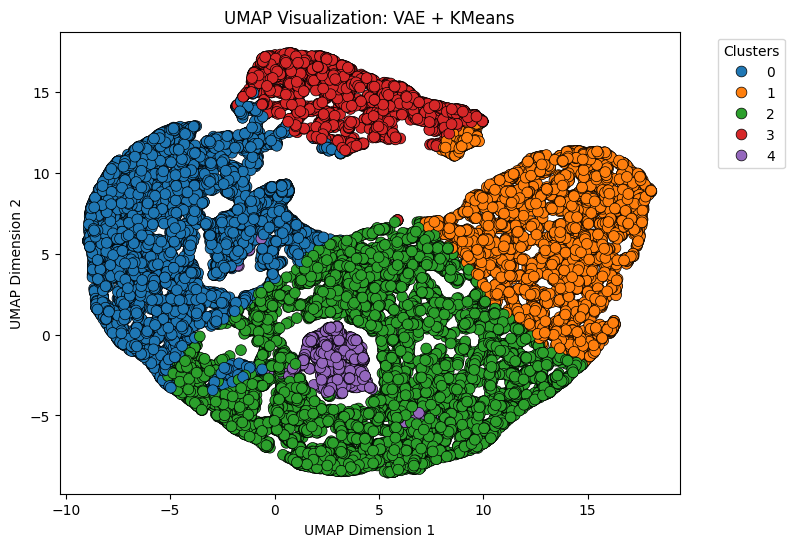

In [43]:
import umap
# KMeans
kmeans_vae = KMeans(n_clusters=5, random_state=42)
clusters_vae = kmeans_vae.fit_predict(latent_features)

# UMAP 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
vae_umap_2d = reducer.fit_transform(latent_features)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x = vae_umap_2d[:,0], y =vae_umap_2d[:,1], hue=clusters_vae, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


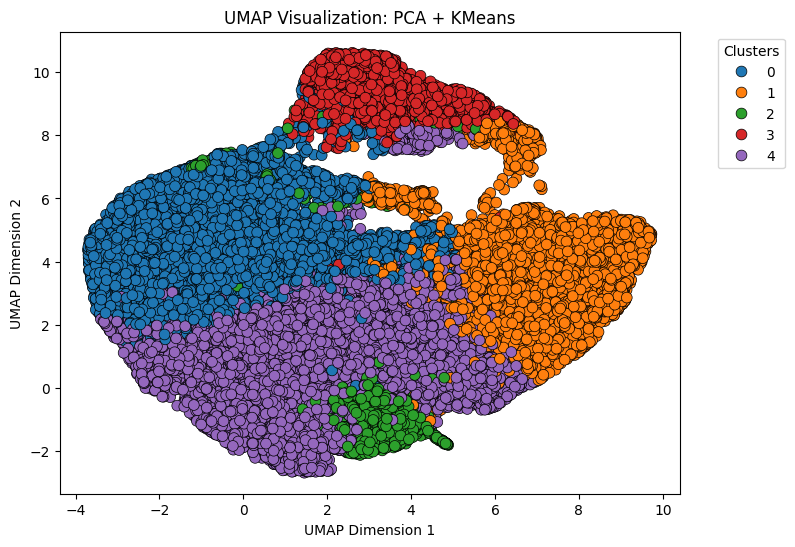

In [44]:
# Reduce input features via PCA first
pca = PCA(n_components=5)  # same as VAE latent_dim for fair comparison
X_pca = pca.fit_transform(X_scaled)

# KMeans
kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# UMAP 2D
reducer_pca = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
pca_umap_2d = reducer_pca.fit_transform(X_pca)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_umap_2d[:,0], y=pca_umap_2d[:,1], hue=clusters_pca, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: PCA + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


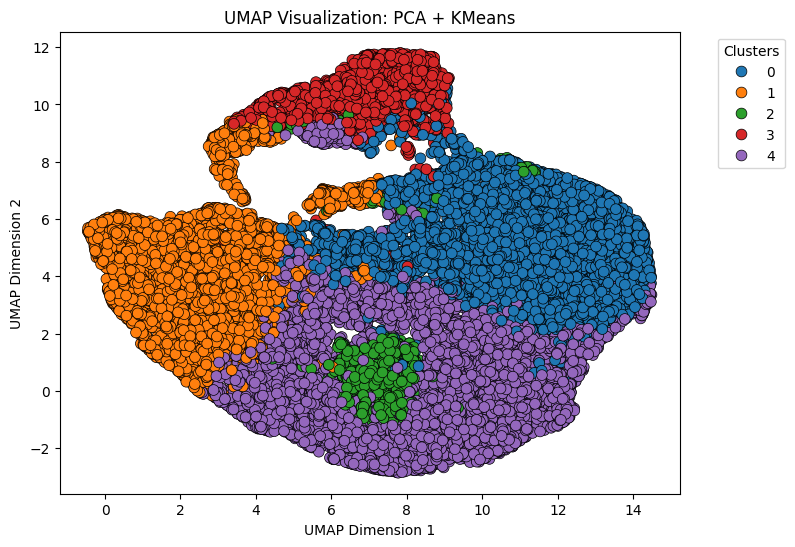

In [45]:
# Reduce input features via PCA first
pca = PCA(n_components=5)  # same as VAE latent_dim for fair comparison
X_pca = pca.fit_transform(X_scaled)

# KMeans
kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# UMAP 2D
reducer_pca = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
pca_umap_2d = reducer_pca.fit_transform(X_pca)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_umap_2d[:,0], y=pca_umap_2d[:,1], hue=clusters_pca, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: PCA + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
